In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd

# Khai báo đường dẫn module gốc
sys.path.append(os.path.abspath(".."))
from core_ntsa.generators import simulate_lorenz
from core_ntsa.noise_tools import add_white_noise
from core_ntsa.phase_space_reconstruction import delay_embedding, false_nearest_neighbors
# =====================================================================
# 1. ĐẦU VÀO (INPUT)
# =====================================================================
print("Đang khởi tạo dữ liệu và bơm nhiễu...")

# Lấy trục X của Lorenz và bơm nhiễu trắng (SNR = 15 dB)
lorenz_data = simulate_lorenz(t_span=50.0, dt=0.01)
clean_x = lorenz_data[0]
noisy_x = add_white_noise(clean_x, snr_db=15.0)
N_T = len(noisy_x)

Đang khởi tạo dữ liệu và bơm nhiễu...


2. Đang quét không gian pha từ d=1 đến d=10...
3. Vẽ đồ thị kết quả...


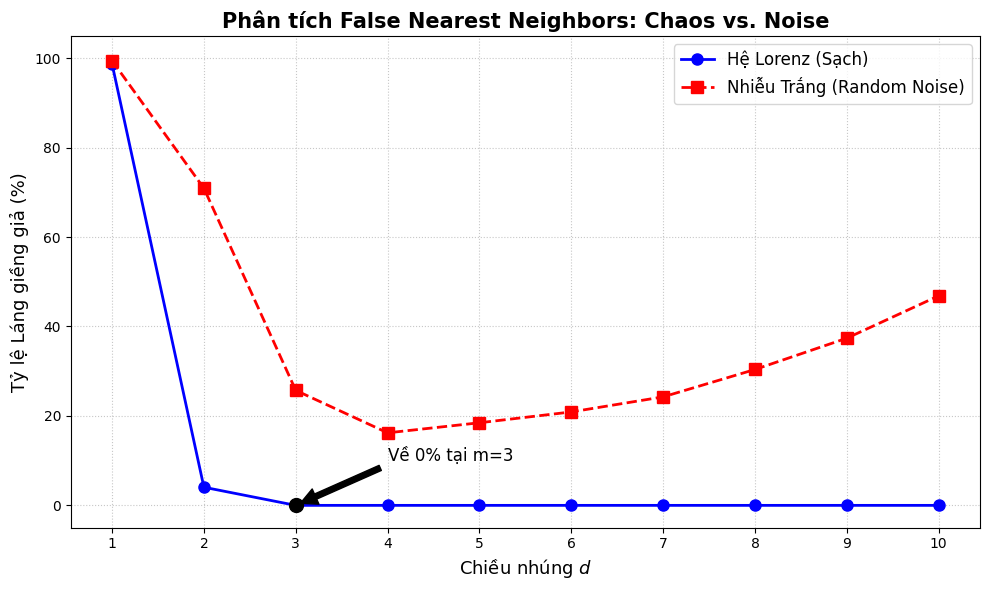

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt



# Kịch bản 2: Nhiễu trắng thuần túy (Random Noise)
# Dùng phương sai tương đương với Lorenz để so sánh công bằng
noise_variance = np.std(clean_x) 
pure_noise = np.random.normal(0, noise_variance, len(clean_x))

# =====================================================================
# 2. CHẠY THUẬT TOÁN FNN
# =====================================================================
print("2. Đang quét không gian pha từ d=1 đến d=10...")
# Sử dụng tau = 15 cho Lorenz (đã chứng minh ở các bài test KSG trước)
tau_optimal = 15

# Chạy FNN
dims_lorenz, fnn_lorenz = false_nearest_neighbors(clean_x, tau=tau_optimal, max_m=10)
dims_noise, fnn_noise = false_nearest_neighbors(pure_noise, tau=tau_optimal, max_m=10)

# =====================================================================
# 3. TRỰC QUAN HÓA SO SÁNH
# =====================================================================
print("3. Vẽ đồ thị kết quả...")
plt.figure(figsize=(10, 6))
plt.title("Phân tích False Nearest Neighbors: Chaos vs. Noise", fontsize=15, fontweight='bold')

# Đường Lorenz
plt.plot(dims_lorenz, fnn_lorenz, marker='o', markersize=8, linewidth=2, 
         color='blue', label='Hệ Lorenz (Sạch)')

# Đường Nhiễu thuần túy
plt.plot(dims_noise, fnn_noise, marker='s', markersize=8, linewidth=2, linestyle='--',
         color='red', label='Nhiễu Trắng (Random Noise)')

# Điểm nhấn d=3 của Lorenz
plt.scatter(3, fnn_lorenz[2], color='black', s=100, zorder=5)
plt.annotate('Về 0% tại m=3', xy=(3, fnn_lorenz[2]), xytext=(4, 10),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12)

plt.xlabel('Chiều nhúng $d$', fontsize=13)
plt.ylabel('Tỷ lệ Láng giềng giả (%)', fontsize=13)
plt.xticks(np.arange(1, 11))
plt.ylim(-5, 105)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

1. Đang sinh dữ liệu và bơm nhiễu...
2. Đang quét không gian pha từ d=1 đến d=10...
3. Vẽ đồ thị kết quả...


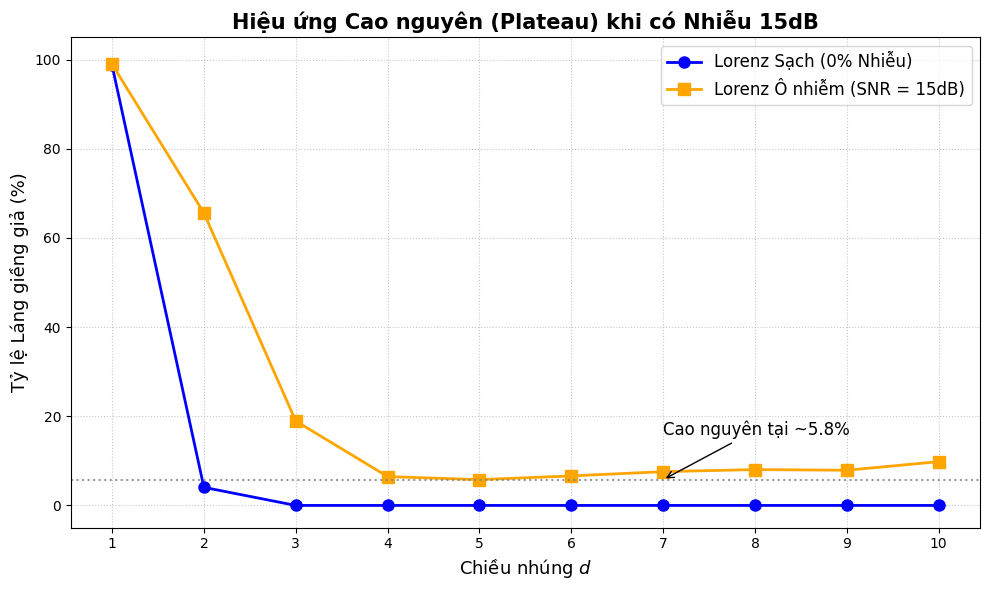

In [4]:
# =====================================================================
# 1. KHỞI TẠO DỮ LIỆU (KỊCH BẢN THỰC TẾ)
# =====================================================================
print("1. Đang sinh dữ liệu và bơm nhiễu...")
lorenz_data = simulate_lorenz(t_span=50.0, dt=0.01)
clean_x = lorenz_data[0]

# Bơm nhiễu 15dB để tạo ra "Sương mù" bao phủ quỹ đạo
noisy_x = add_white_noise(clean_x, snr_db=5.0)

# =====================================================================
# 2. CHẠY THUẬT TOÁN FNN
# =====================================================================
print("2. Đang quét không gian pha từ d=1 đến d=10...")
tau_optimal = 15

# Quét cả 2 chuỗi để đối chiếu trực tiếp
dims, fnn_clean = false_nearest_neighbors(clean_x, tau=tau_optimal, max_m=10)
dims, fnn_noisy = false_nearest_neighbors(noisy_x, tau=tau_optimal, max_m=10)

# =====================================================================
# 3. TRỰC QUAN HÓA SO SÁNH
# =====================================================================
print("3. Vẽ đồ thị kết quả...")
plt.figure(figsize=(10, 6))
plt.title("Hiệu ứng Cao nguyên (Plateau) khi có Nhiễu 15dB", fontsize=15, fontweight='bold')

plt.plot(dims, fnn_clean, marker='o', markersize=8, linewidth=2, color='blue', label='Lorenz Sạch (0% Nhiễu)')
plt.plot(dims, fnn_noisy, marker='s', markersize=8, linewidth=2, linestyle='-', color='orange', label='Lorenz Ô nhiễm (SNR = 15dB)')

# Vẽ đường gióng ngang để làm nổi bật Cao nguyên
min_fnn_noisy = np.min(fnn_noisy)
plt.axhline(y=min_fnn_noisy, color='gray', linestyle=':', alpha=0.8)
plt.annotate(f'Cao nguyên tại ~{min_fnn_noisy:.1f}%', xy=(7, min_fnn_noisy), xytext=(7, min_fnn_noisy + 10),
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=12)

plt.xlabel('Chiều nhúng $d$', fontsize=13)
plt.ylabel('Tỷ lệ Láng giềng giả (%)', fontsize=13)
plt.xticks(np.arange(1, 11))
plt.ylim(-5, 105)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()